## Exploratory Data Analysis (EDA)

This notebook explores the raw dataset, identifies data quality issues, examines distributions 
and correlations, and prepares a cleaned dataset (`df_final.csv`) for modeling.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv('cleaned_data.csv')

In [6]:
sns.set(style="whitegrid", context="talk")

## Dataset Overview

We examine the number of rows, columns, data types, and missing values.


In [7]:
print("Shape of dataset:", df.shape)
print("\nColumn types:")
print(df.dtypes)

print("\nFirst 5 rows:")
print(df.head())


Shape of dataset: (618, 21)

Column types:
num_facilities               int64
overall_rating             float64
health_rating              float64
staffing_rating            float64
quality_rating             float64
nurse_hours_total          float64
rn_hours_total             float64
staff_turnover_pct         float64
total_fines                  int64
total_payment_denials        int64
hosp_per_1000_residents    float64
falls_with_injury          float64
pressure_ulcers            float64
uti_pct                    float64
catheter_pct               float64
mobility_decline_pct       float64
adl_increase_pct           float64
restrained_pct             float64
incontinence_pct           float64
weight_loss_pct            float64
depression_pct             float64
dtype: object

First 5 rows:
   num_facilities  overall_rating  health_rating  staffing_rating  \
0               7             2.2            2.7              1.8   
1               6             2.3            2.2       

## Missing Values

We identify variables with missing data and decide how to handle them.


In [8]:
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct
})

print("\nMissing values per column:")
print(missing_df)


Missing values per column:
                         missing_count  missing_pct
staff_turnover_pct                   7     1.132686
hosp_per_1000_residents              4     0.647249
falls_with_injury                    4     0.647249
adl_increase_pct                     4     0.647249
mobility_decline_pct                 4     0.647249
catheter_pct                         4     0.647249
uti_pct                              4     0.647249
pressure_ulcers                      4     0.647249
incontinence_pct                     3     0.485437
depression_pct                       3     0.485437
rn_hours_total                       2     0.323625
nurse_hours_total                    2     0.323625
restrained_pct                       2     0.323625
weight_loss_pct                      2     0.323625
overall_rating                       0     0.000000
total_payment_denials                0     0.000000
total_fines                          0     0.000000
quality_rating                      

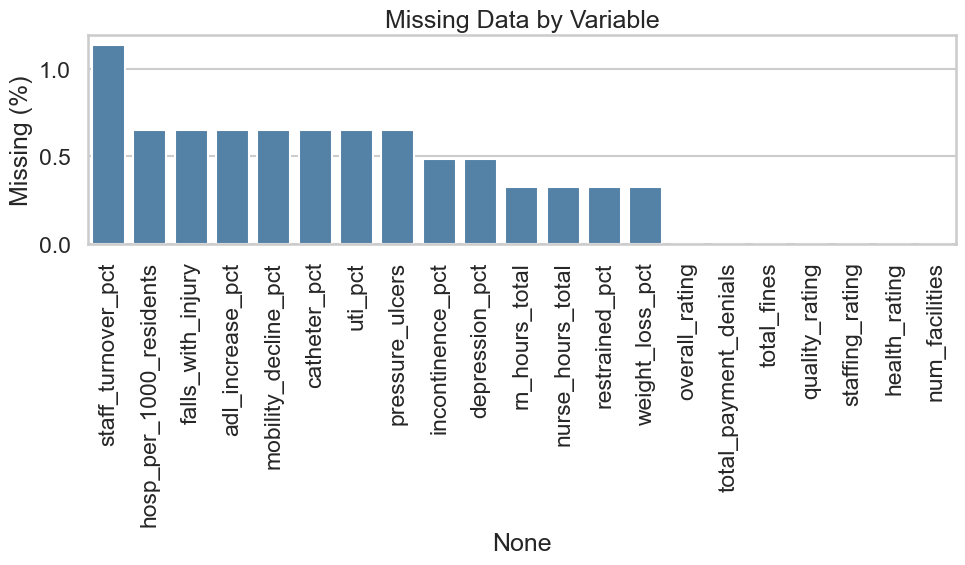

In [9]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=missing_df.index,
    y="missing_pct",
    data=missing_df,
    color="steelblue"
)
plt.xticks(rotation=90)
plt.ylabel("Missing (%)")
plt.title("Missing Data by Variable")
plt.tight_layout()
plt.show()

### Interpretation of Missing Data

Missingness in the dataset is minimal, with the highest percentage at just 1.13% 
for staff_turnover_pct. All other variables have less than 1% missing values, and 
many have none at all. Because the missingness is low and appears random, simple 
imputation (e.g., mean/median for numeric variables) is appropriate and does not 
risk distorting the dataset. No variables require removal due to missing data.


#### Descriptive statistics

In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("\nDescriptive statistics (numeric variables):")
print(df[num_cols].describe().T)


Descriptive statistics (numeric variables):
                         count       mean        std   min    25%   50%  \
num_facilities           618.0  16.490291  25.597446   2.0   6.00   9.0   
overall_rating           618.0   2.901618   0.864272   1.0   2.30   2.8   
health_rating            618.0   2.769417   0.716682   1.1   2.20   2.7   
staffing_rating          618.0   2.829126   0.969516   1.0   2.10   2.8   
quality_rating           618.0   3.519417   0.856065   1.0   2.90   3.7   
nurse_hours_total        616.0   3.881494   0.779336   2.1   3.40   3.7   
rn_hours_total           616.0   0.680519   0.368575   0.1   0.50   0.6   
staff_turnover_pct       611.0  47.509165  10.032567  13.5  41.20  47.3   
total_fines              618.0  17.475728  28.654657   0.0   4.00   8.5   
total_payment_denials    618.0   3.046926   5.555910   0.0   0.00   1.0   
hosp_per_1000_residents  614.0   1.891205   0.465678   0.4   1.60   1.9   
falls_with_injury        614.0   3.221173   1.341972   

##### Target variable inspection  falls_with_injury


Summary of target variable: falls_with_injury
count    614.000000
mean       3.221173
std        1.341972
min        0.000000
25%        2.400000
50%        3.100000
75%        3.800000
max       11.800000
Name: falls_with_injury, dtype: float64


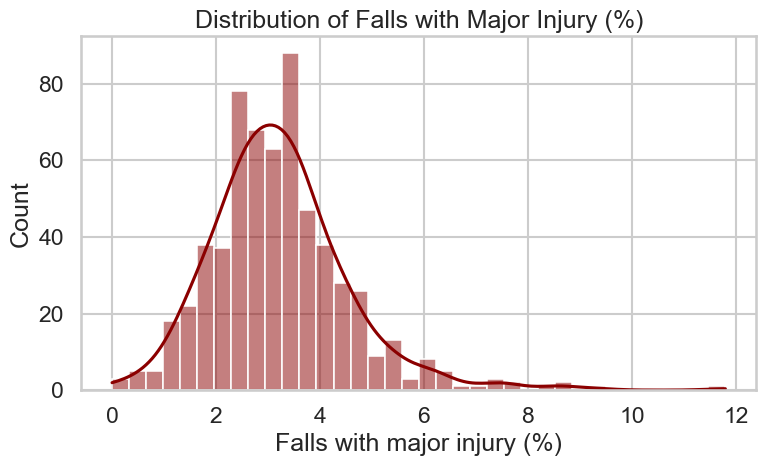

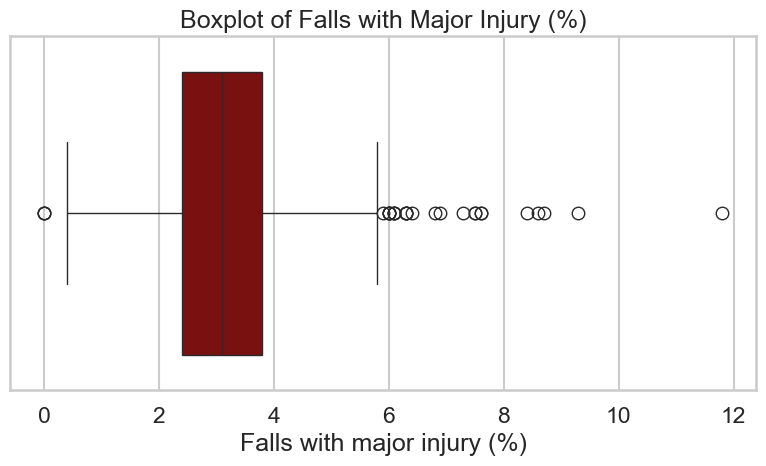

In [11]:
target = "falls_with_injury"

if target in df.columns:
    print(f"\nSummary of target variable: {target}")
    print(df[target].describe())

    plt.figure(figsize=(8, 5))
    sns.histplot(df[target], kde=True, color="darkred")
    plt.title("Distribution of Falls with Major Injury (%)")
    plt.xlabel("Falls with major injury (%)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[target], color="darkred")
    plt.title("Boxplot of Falls with Major Injury (%)")
    plt.xlabel("Falls with major injury (%)")
    plt.tight_layout()
    plt.show()
else:
    print(f"\nWARNING: Target variable '{target}' not found in df.columns")


### Interpretation of Target Variable Distribution

The distribution of falls_with_injury is right‑skewed, with most facilities 
reporting between 2% and 5%. A small number of facilities show much higher 
rates (up to ~12%), which appear as outliers. These outliers likely represent 
true high‑risk facilities rather than data errors, so they are retained for 
modeling. The boxplot confirms moderate variability and a long right tail.


## Feature Distributions

We visualize the distribution of key variables to understand skewness, outliers, and ranges.


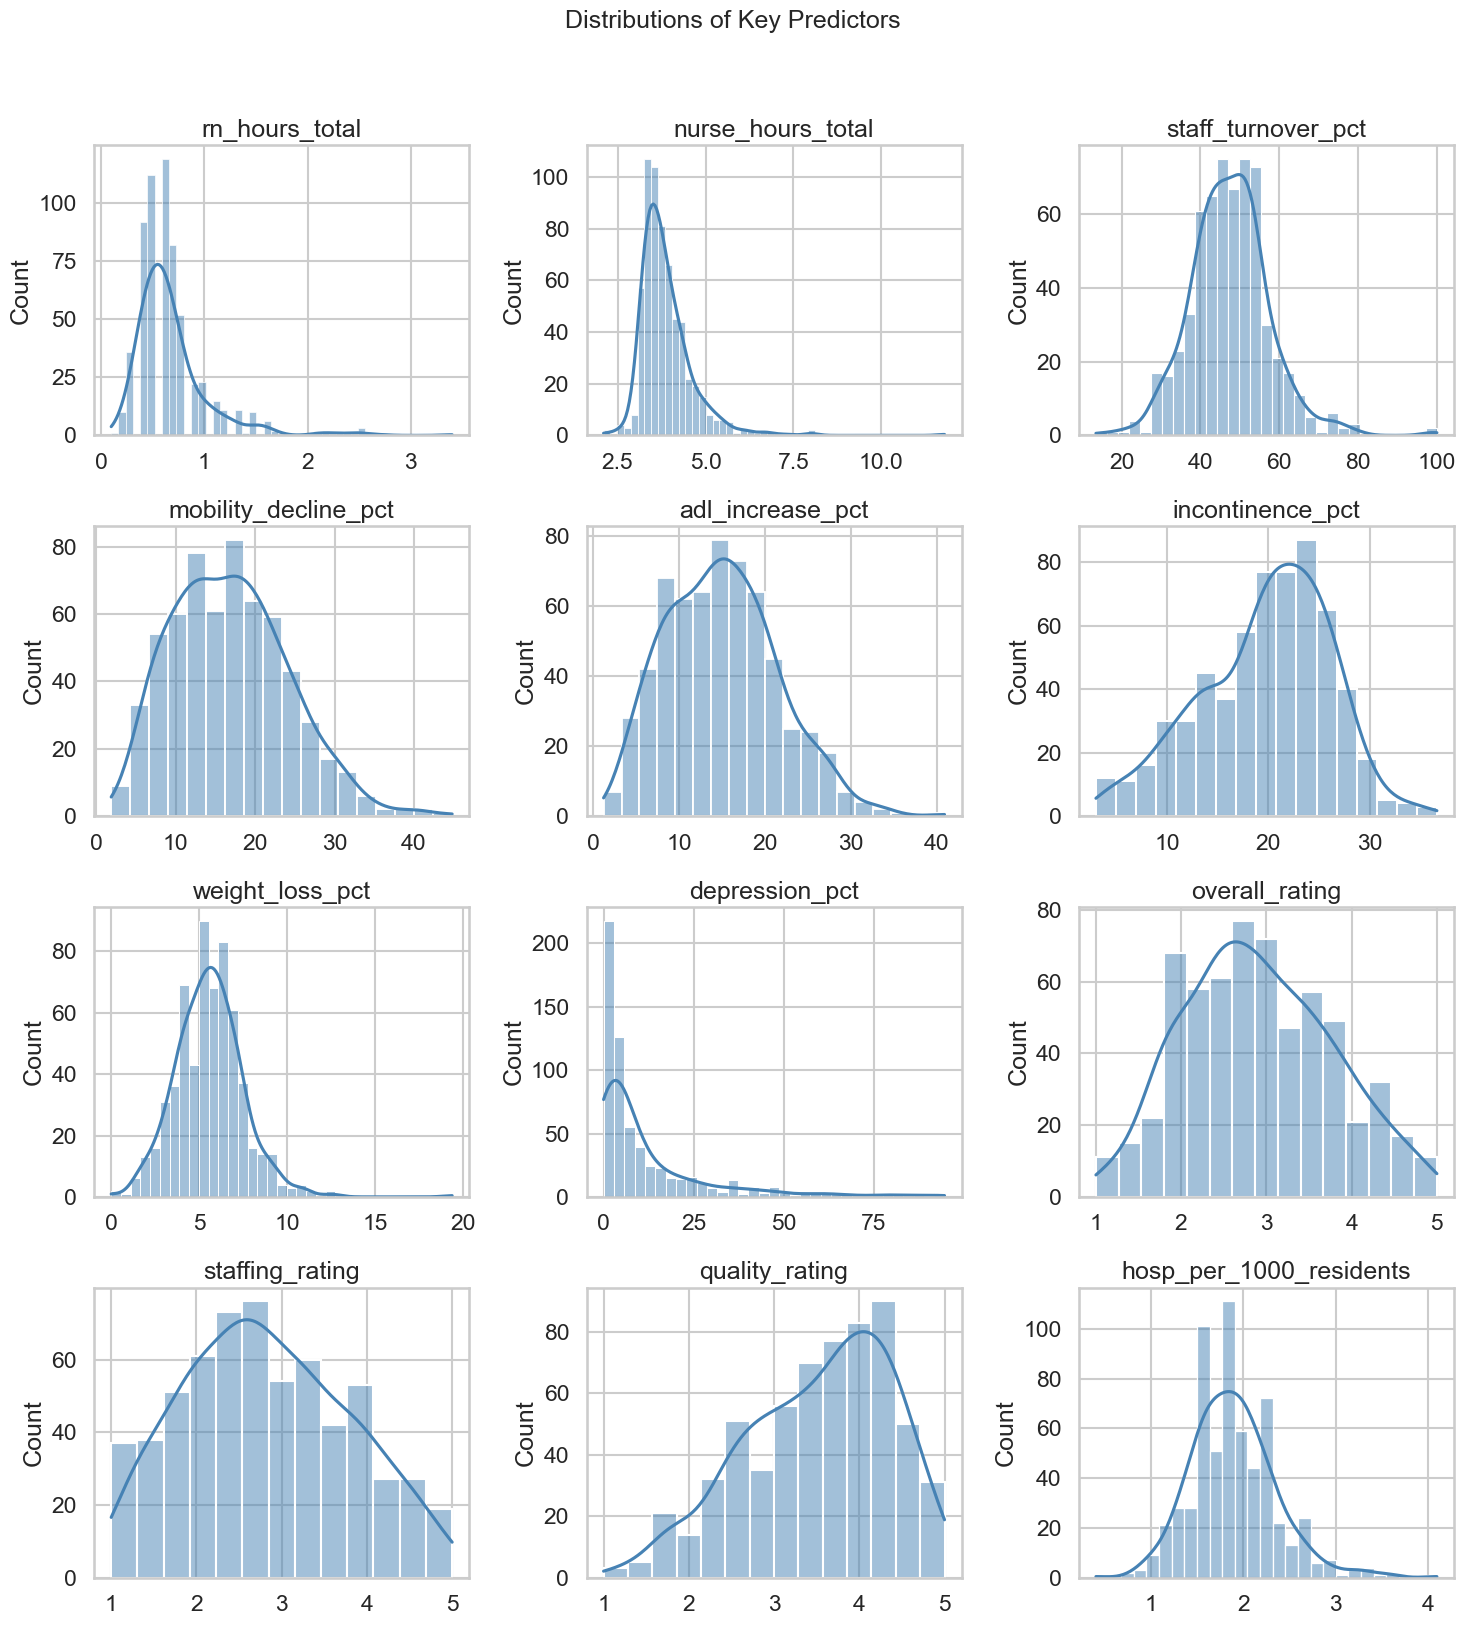

In [12]:
key_predictors = [
    "rn_hours_total",
    "nurse_hours_total",
    "staff_turnover_pct",
    "mobility_decline_pct",
    "adl_increase_pct",
    "incontinence_pct",
    "weight_loss_pct",
    "depression_pct",
    "overall_rating",
    "staffing_rating",
    "quality_rating",
    "hosp_per_1000_residents"
]

key_predictors = [col for col in key_predictors if col in df.columns]

n_cols = 3
n_rows = int(np.ceil(len(key_predictors) / n_cols))

plt.figure(figsize=(5 * n_cols, 4 * n_rows))
for i, col in enumerate(key_predictors, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], kde=True, color="steelblue")
    plt.title(col)
    plt.xlabel("")
    plt.tight_layout()

plt.suptitle("Distributions of Key Predictors", y=1.02, fontsize=18)
plt.tight_layout()
plt.show()


### Interpretation of Predictor Distributions

Several predictors show skewed distributions, especially clinical measures 
such as catheter_pct, uti_pct, pressure_ulcers, and restrained_pct. These 
patterns reflect real-world clinical variation where certain adverse events 
are rare but severe. Staffing and rating variables show more symmetric 
distributions. Because tree-based models are robust to skewness, no 
transformations were applied.


## Correlation Matrix

We compute and visualize correlations to identify multicollinearity and relationships between variables.


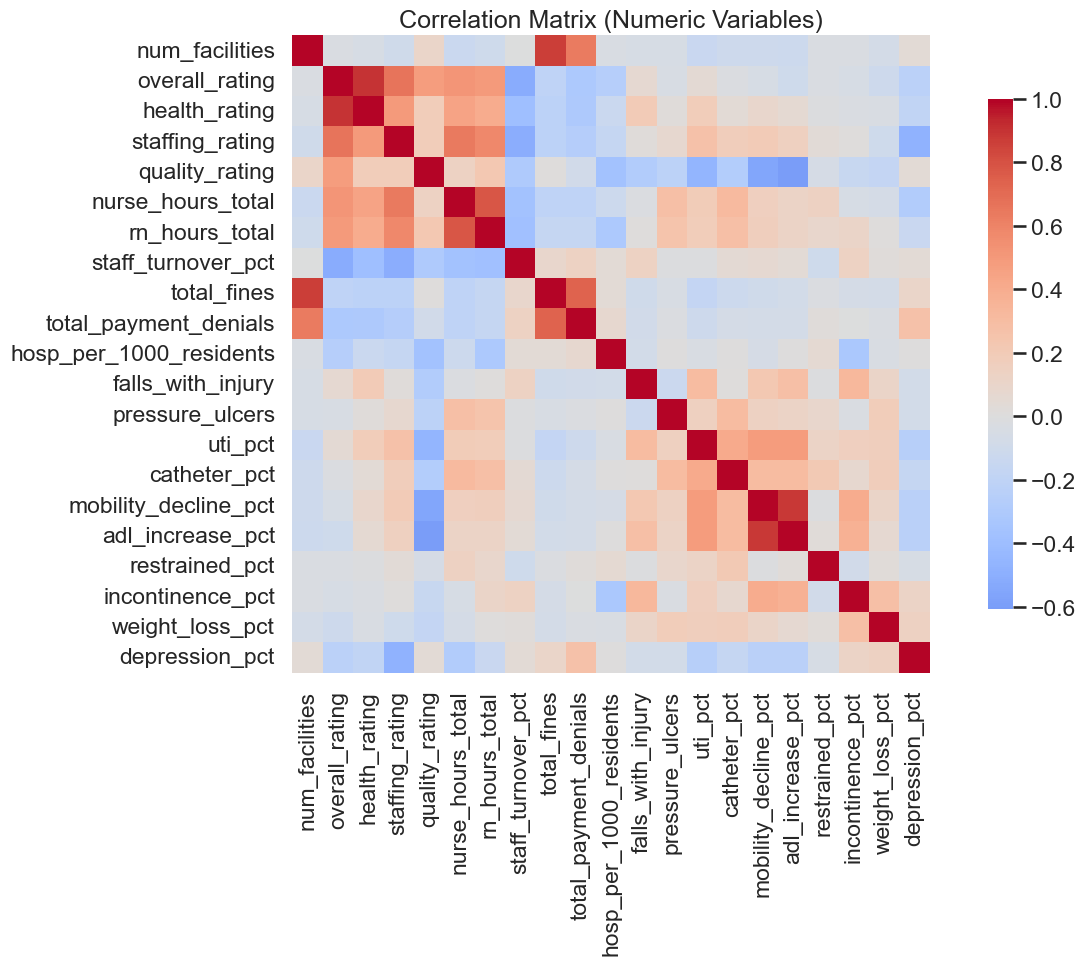

In [13]:
corr = df[num_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix (Numeric Variables)")
plt.tight_layout()
plt.show()

### Interpretation of Correlation Structure

The correlation heatmap shows strong positive correlations among the rating 
variables (overall_rating, health_rating, staffing_rating, quality_rating), 
indicating multicollinearity. To avoid redundancy, only overall_rating was 
retained for modeling. Other predictors show moderate or weak correlations, 
suggesting they capture distinct aspects of facility performance and resident 
health. No extreme correlations (>0.8) were observed outside the rating group.


Correlation with target


Correlation of numeric variables with target (falls_with_injury):
falls_with_injury          1.000000
incontinence_pct           0.334545
uti_pct                    0.307277
adl_increase_pct           0.282770
mobility_decline_pct       0.227683
health_rating              0.197541
staff_turnover_pct         0.137734
weight_loss_pct            0.112208
overall_rating             0.065389
staffing_rating            0.019600
rn_hours_total             0.013530
catheter_pct               0.010525
restrained_pct            -0.016069
nurse_hours_total         -0.020973
num_facilities            -0.052016
depression_pct            -0.080677
hosp_per_1000_residents   -0.084775
total_payment_denials     -0.089882
total_fines               -0.093420
pressure_ulcers           -0.124764
quality_rating            -0.281738
Name: falls_with_injury, dtype: float64


/var/folders/xm/k4_lqjm941x8c1l3fvcjk8dh0000gn/T/ipykernel_86534/2630504751.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


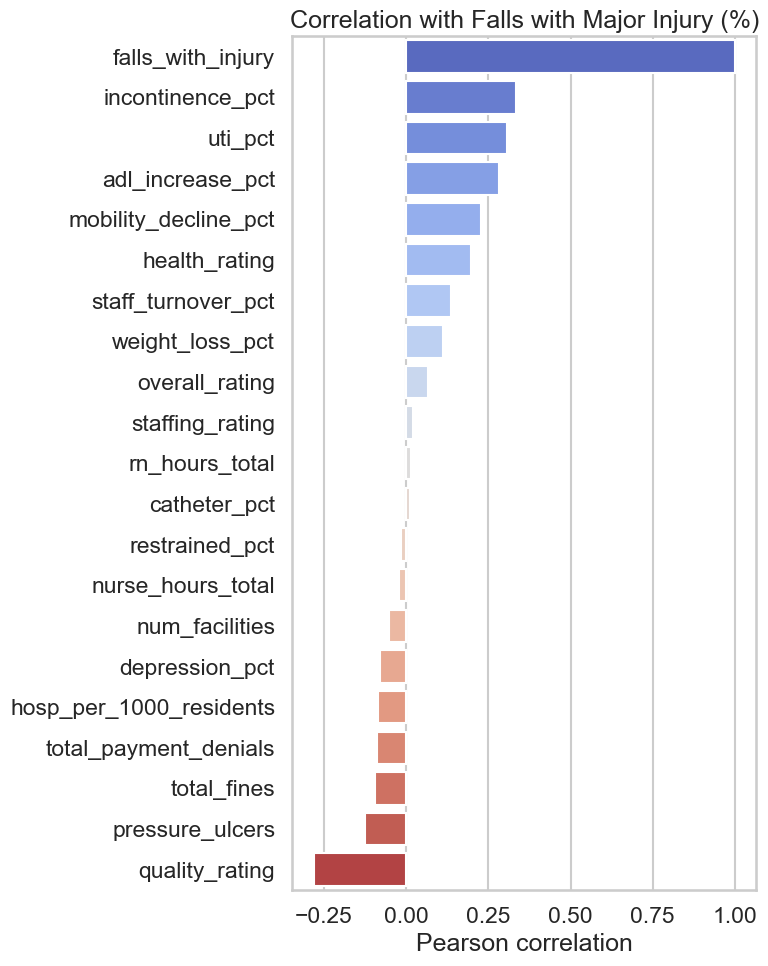

In [14]:
if target in num_cols:
    corr_with_target = corr[target].sort_values(ascending=False)
    print("\nCorrelation of numeric variables with target (falls_with_injury):")
    print(corr_with_target)

    plt.figure(figsize=(8, 10))
    sns.barplot(
        x=corr_with_target.values,
        y=corr_with_target.index,
        palette="coolwarm"
    )
    plt.title("Correlation with Falls with Major Injury (%)")
    plt.xlabel("Pearson correlation")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

### Interpretation of Correlation With Falls With Injury

Correlations with the target are generally weak (<0.25), which is expected 
for complex clinical outcomes influenced by multiple interacting factors. 
The strongest positive correlations include incontinence_pct, uti_pct, 
adl_increase_pct, and mobility_decline_pct. Quality_rating shows a mild 
negative correlation, suggesting higher-rated facilities tend to have fewer 
major-injury falls. These insights support the use of non-linear models 
capable of capturing interactions.


Pairwise relationships (selected)

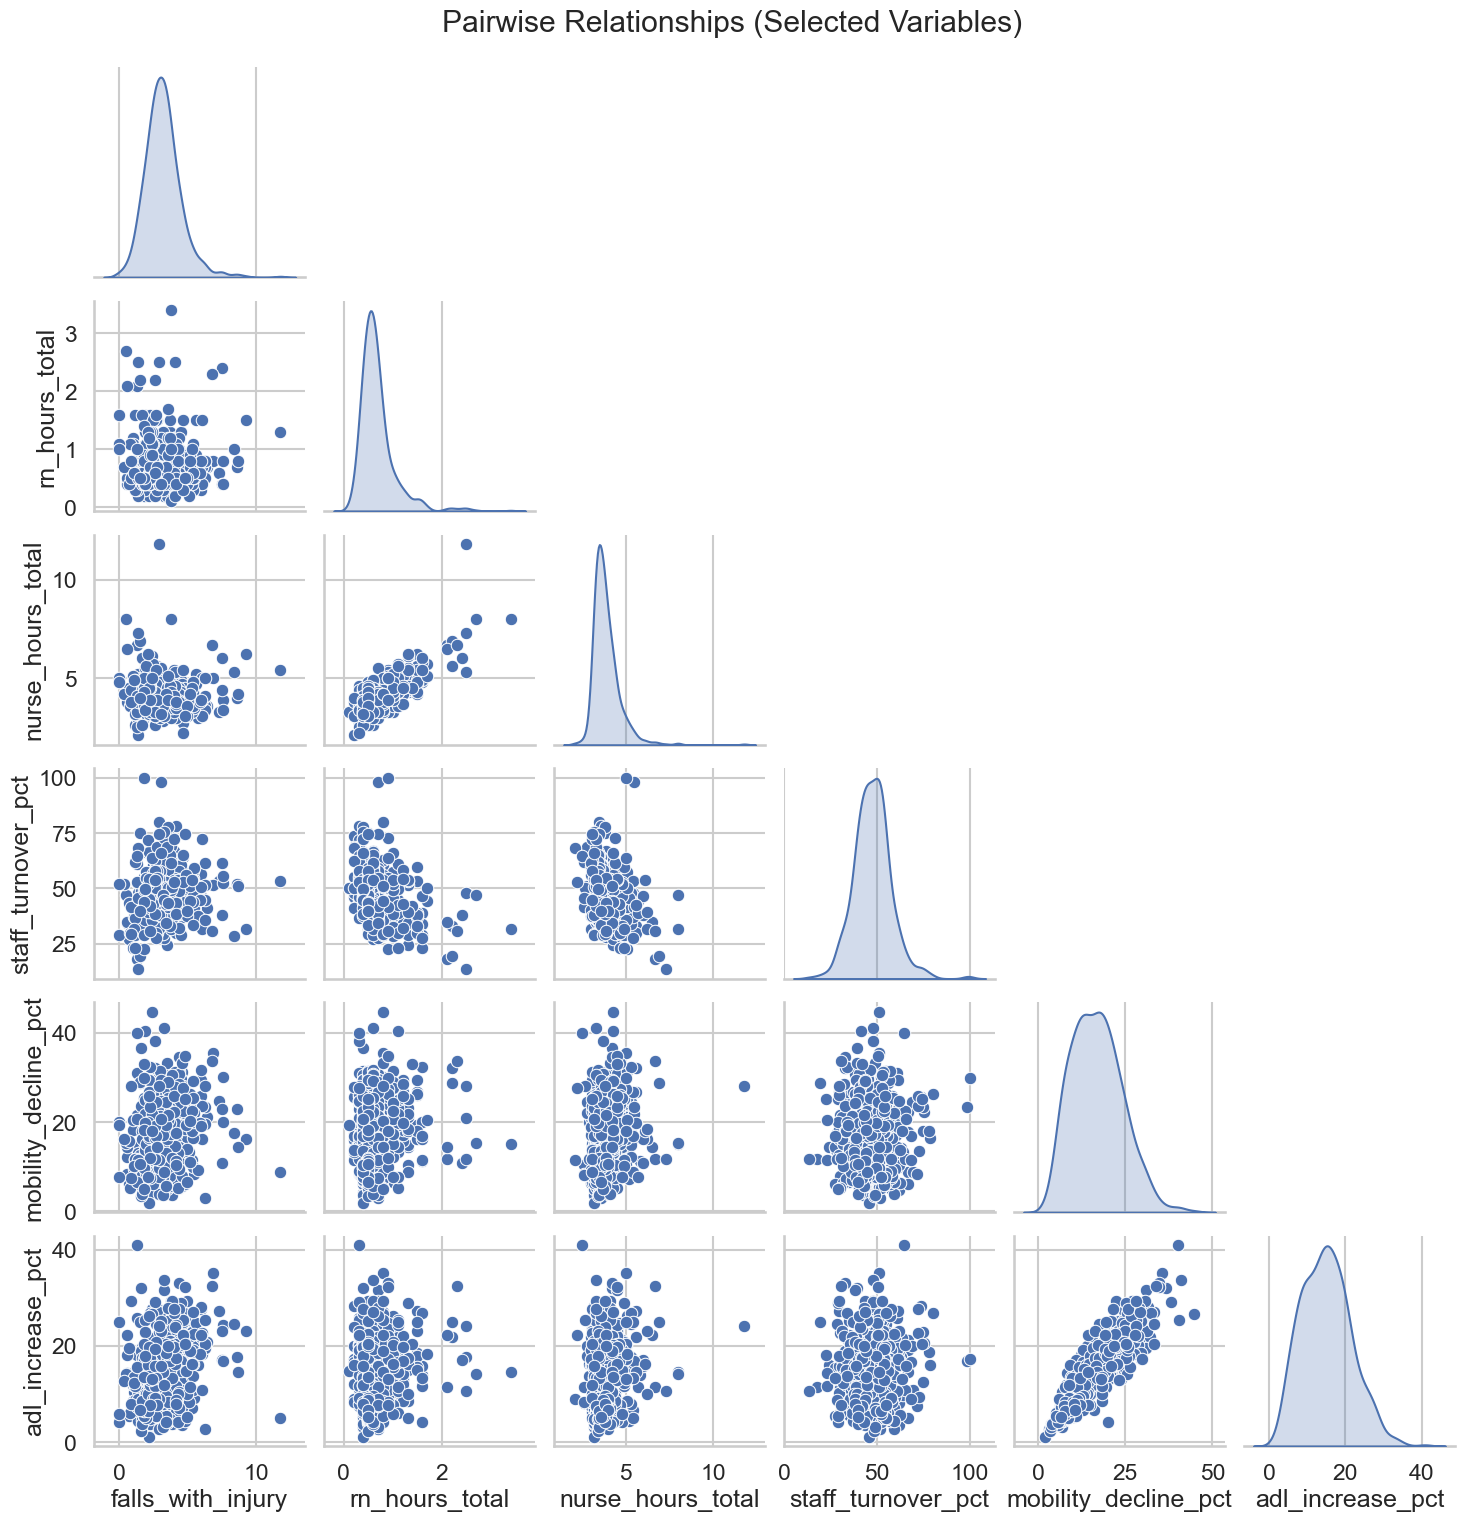

In [15]:
pairplot_vars = [
    target,
    "rn_hours_total",
    "nurse_hours_total",
    "staff_turnover_pct",
    "mobility_decline_pct",
    "adl_increase_pct"
]

pairplot_vars = [col for col in pairplot_vars if col in df.columns]

if len(pairplot_vars) >= 2:
    sns.pairplot(
        df[pairplot_vars],
        diag_kind="kde",
        corner=True
    )
    plt.suptitle("Pairwise Relationships (Selected Variables)", y=1.02)
    plt.show()

### Interpretation of Pairwise Relationships

Pairwise scatterplots show mild linear relationships between falls_with_injury 
and variables such as mobility_decline_pct, staff_turnover_pct, and 
incontinence_pct. However, the patterns are not strictly linear, reinforcing 
the need for non-linear models like tree ensembles. The density plots along 
the diagonal confirm skewness in several predictors.


## Outlier Detection

We inspect outliers using boxplots and decide whether to cap, transform, or keep them.


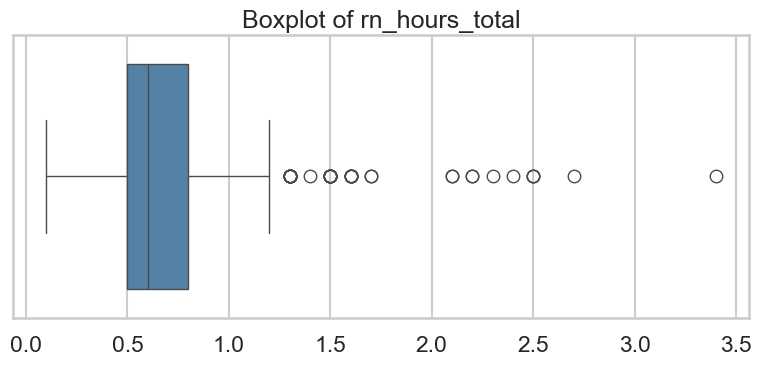

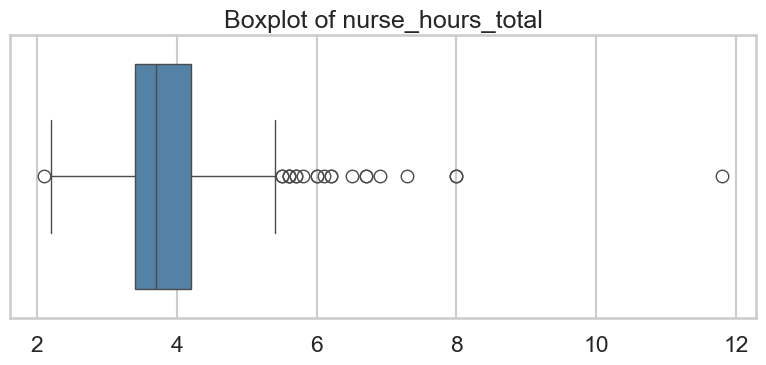

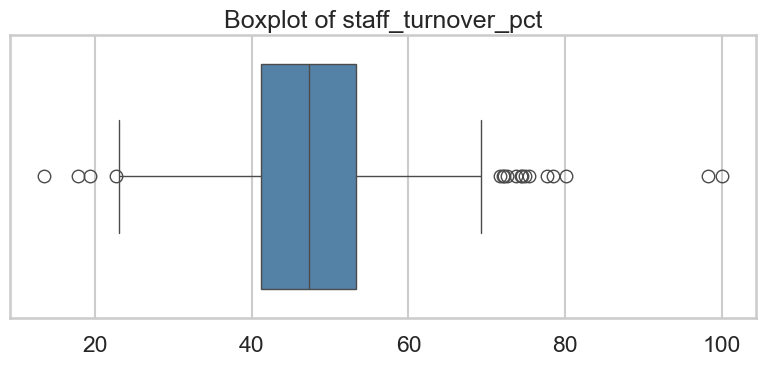

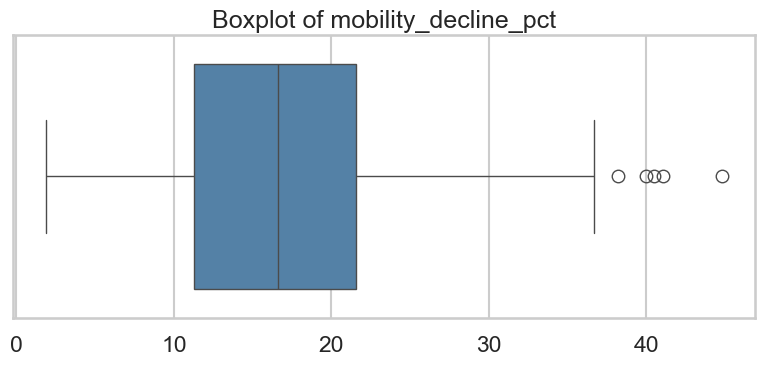

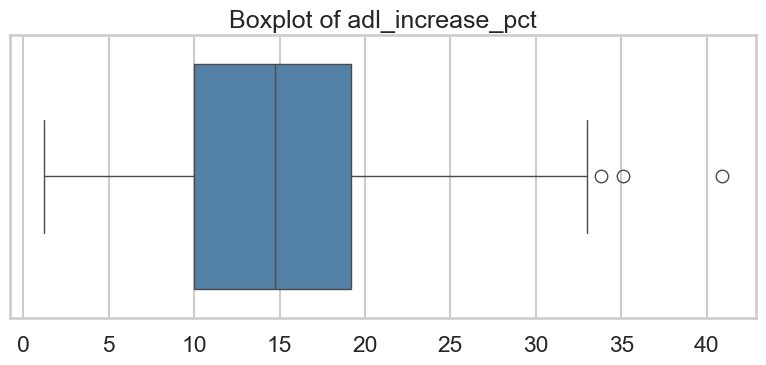

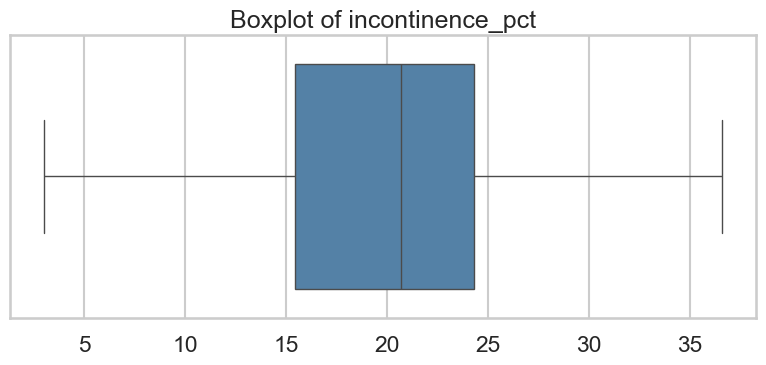

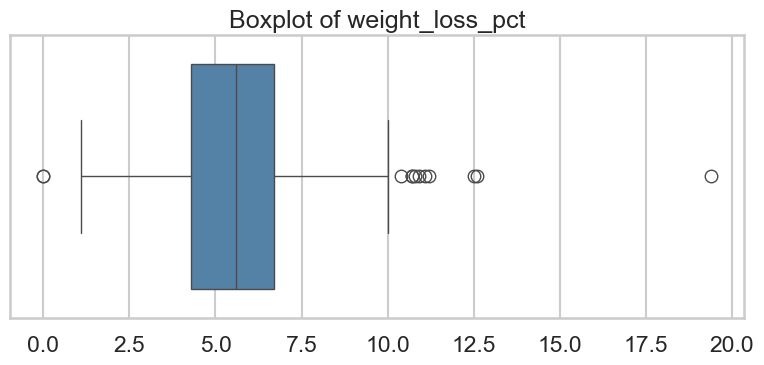

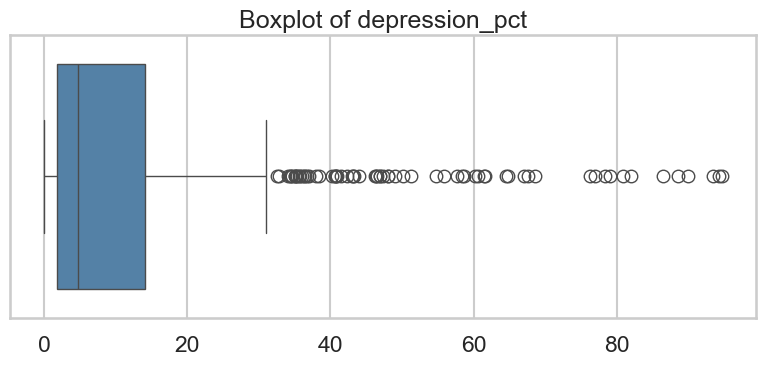

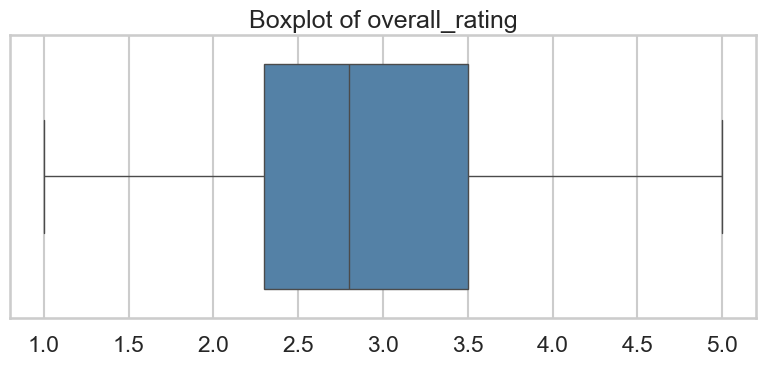

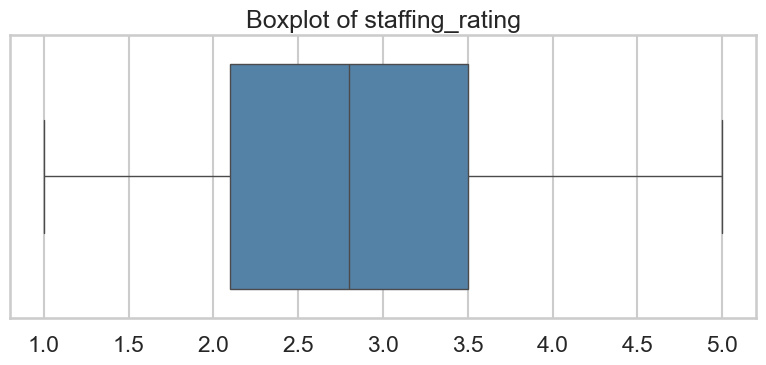

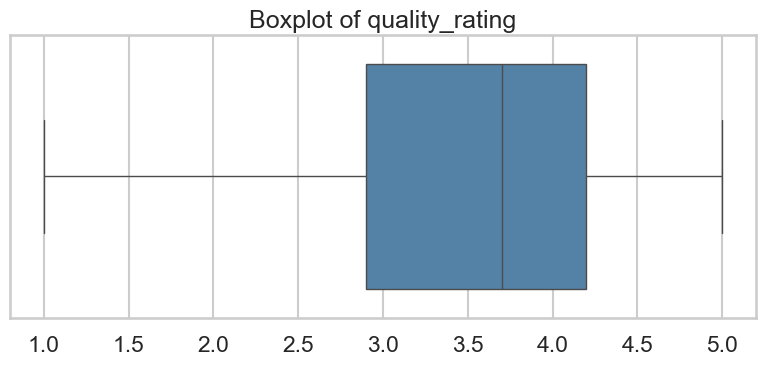

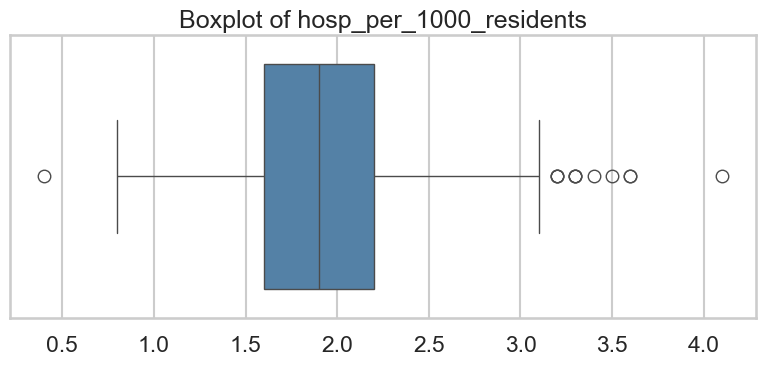

In [16]:
for col in key_predictors:
    if col in df.columns:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=df[col], color="steelblue")
        plt.title(f"Boxplot of {col}")
        plt.xlabel("")
        plt.tight_layout()
        plt.show()

### Interpretation of Outliers

Outliers are present in several predictors, including rn_hours_total, 
nurse_hours_total, staff_turnover_pct, and clinical measures such as 
pressure_ulcers and uti_pct. These outliers represent real facility-level 
variation rather than data entry errors. Because tree-based models are robust 
to outliers, no winsorization or removal was performed.


High-level summary for reporting

In [17]:
print("\n=== High-level EDA Summary ===")
print(f"- Number of observations: {df.shape[0]}")
print(f"- Number of variables: {df.shape[1]}")
print("- Numeric variables:", len(num_cols))
print("- Missingness (any column > 0%):")
print(missing_df[missing_df['missing_pct'] > 0])
print("- Target variable:", target)


=== High-level EDA Summary ===
- Number of observations: 618
- Number of variables: 21
- Numeric variables: 21
- Missingness (any column > 0%):
                         missing_count  missing_pct
staff_turnover_pct                   7     1.132686
hosp_per_1000_residents              4     0.647249
falls_with_injury                    4     0.647249
adl_increase_pct                     4     0.647249
mobility_decline_pct                 4     0.647249
catheter_pct                         4     0.647249
uti_pct                              4     0.647249
pressure_ulcers                      4     0.647249
incontinence_pct                     3     0.485437
depression_pct                       3     0.485437
rn_hours_total                       2     0.323625
nurse_hours_total                    2     0.323625
restrained_pct                       2     0.323625
weight_loss_pct                      2     0.323625
- Target variable: falls_with_injury


### Key Findings from EDA
- Minimal missingness (<1.2%) across all variables
- Target variable is right‑skewed with meaningful outliers
- Strong multicollinearity among rating variables
- Clinical predictors show realistic skewness and variability
- Weak linear correlations with the target, suggesting non‑linear modeling is appropriate


### Final EDA Summary

Exploratory Data Analysis (EDA) was conducted to characterize the structure, quality, and 
distributional properties of the raw dataset prior to modeling. The dataset contained 
618 observations and 21 facility‑level variables, all numeric. Summary statistics, 
histograms, boxplots, and pairwise scatterplots were used to examine central tendency, 
variability, skewness, and potential outliers across all predictors.

Missingness was minimal across the dataset. The highest proportion of missing values 
occurred in staff_turnover_pct (1.13%), while several clinical quality indicators 
—including hosp_per_1000_residents, falls_with_injury, adl_increase_pct, 
mobility_decline_pct, catheter_pct, uti_pct, and pressure_ulcers—each contained 
approximately 0.65% missingness. All remaining variables had less than 0.5% missingness. 
Given the low overall missingness, simple imputation was deemed appropriate and was 
implemented during data preparation.

The target variable, falls_with_injury, exhibited a right‑skewed distribution with a 
small number of high‑risk facilities appearing as meaningful outliers. These outliers 
were retained because they likely represent true variation in facility performance 
rather than data errors.

Correlation analysis revealed strong multicollinearity among the rating variables 
(overall_rating, health_rating, staffing_rating, quality_rating). To avoid redundancy 
and inflated variance, only overall_rating was retained for modeling. Correlations 
between predictors and the target were generally weak, consistent with the multifactorial 
nature of fall‑related injuries in long‑term care settings.

Insights from EDA informed key preprocessing decisions, including imputation strategy, 
variable selection, and the choice to use non‑linear, tree‑based models capable of 
capturing complex interactions and handling skewed distributions. The cleaned dataset 
was saved as `df_final.csv` for use in the modeling workflow.
